In [1]:
# ==========================================
# I. PERSIAPAN SISTEM & LIBRARY
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import time

# Set device ke GPU jika tersedia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device yang digunakan: {device}")

# Fungsi untuk menghitung jumlah parameter model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device yang digunakan: cuda


In [2]:
# ==========================================
# II. IMPLEMENTASI TEXT CLASSIFICATION
# ==========================================
print("Mengunduh dan memproses Dataset Sentimen Twitter Indonesia...")
url = "https://raw.githubusercontent.com/rizalespe/Dataset-Sentimen-Analisis-Bahasa-Indonesia/master/dataset_tweet_sentiment_cellular_service_provider.csv"
df = pd.read_csv(url)

# Mapping sentimen ke angka
sentiment_map = {'positive': 0, 'neutral': 1, 'negative': 2}
df['label'] = df['Sentiment'].map(sentiment_map)

# Tokenizer Sederhana
class SimpleTokenizer:
    def __init__(self, texts, max_vocab=5000):
        from collections import Counter
        words = " ".join(texts).lower().split()
        self.vocab = {word: i+2 for i, (word, _) in enumerate(Counter(words).most_common(max_vocab))}
        self.vocab["<PAD>"] = 0
        self.vocab["<UNK>"] = 1

    def encode(self, text, max_len=64):
        tokens = str(text).lower().split()[:max_len]
        encoded = [self.vocab.get(t, 1) for t in tokens]
        return encoded + [0] * (max_len - len(encoded))

tokenizer = SimpleTokenizer(df['Text Tweet'].values)

# Custom Dataset
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        encoded = self.tokenizer.encode(self.texts[idx], self.max_len)
        return torch.tensor(encoded), torch.tensor(self.labels[idx])

# Split Data
X_train, X_test, y_train, y_test = train_test_split(df['Text Tweet'].values, df['label'].values, test_size=0.2, random_state=42)

# Arsitektur Text Transformer
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.fc = nn.Linear(d_model, 3)
    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        return self.fc(x.mean(dim=1))

# Arsitektur LSTM (Baseline)
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.lstm = nn.LSTM(d_model, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 3)
    def forward(self, x):
        x = self.embedding(x)
        _, (hn, _) = self.lstm(x)
        return self.fc(torch.cat((hn[-2,:,:], hn[-1,:,:]), dim=1))

print("Model Teks Siap!")

Mengunduh dan memproses Dataset Sentimen Twitter Indonesia...
Model Teks Siap!



--- Training Transformer (Seq=64) ---
Epoch 1/5 | Loss: 0.9121 | Acc: 0.4458
Epoch 2/5 | Loss: 0.6918 | Acc: 0.5250
Epoch 3/5 | Loss: 0.7056 | Acc: 0.5167
Epoch 4/5 | Loss: 0.6954 | Acc: 0.5333
Epoch 5/5 | Loss: 0.7024 | Acc: 0.4625
Selesai dalam 2.66 detik

--- Training LSTM (Seq=64) ---
Epoch 1/5 | Loss: 0.8038 | Acc: 0.5458
Epoch 2/5 | Loss: 0.6459 | Acc: 0.7375
Epoch 3/5 | Loss: 0.5836 | Acc: 0.7667
Epoch 4/5 | Loss: 0.5103 | Acc: 0.8458
Epoch 5/5 | Loss: 0.3885 | Acc: 0.8792
Selesai dalam 0.72 detik

--- Training Transformer (Seq=32) ---
Epoch 1/5 | Loss: 0.9140 | Acc: 0.4125
Epoch 2/5 | Loss: 0.7150 | Acc: 0.4792
Epoch 3/5 | Loss: 0.7257 | Acc: 0.5333
Epoch 4/5 | Loss: 0.6956 | Acc: 0.4667
Epoch 5/5 | Loss: 0.6967 | Acc: 0.5333
Selesai dalam 0.54 detik


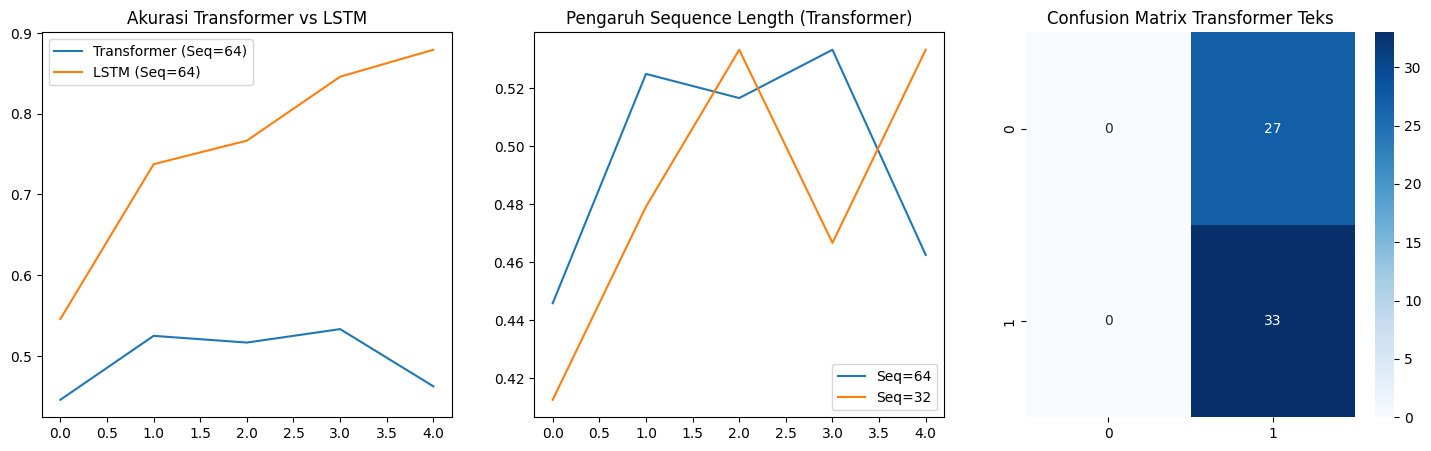


--- Parameter Teks ---
Transformer Teks: 1,345,795 parameter
LSTM: 424,323 parameter


In [3]:
# ==========================================
# FUNGSI TRAINING UMUM
# ==========================================
def train_model(model, loader, epochs=5, model_name="Model"):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()
    hist = {'loss': [], 'acc': []}

    print(f"\n--- Training {model_name} ---")
    start = time.time()
    for epoch in range(epochs):
        model.train()
        l_sum, c_sum, t_sum = 0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()
            l_sum += loss.item(); c_sum += (torch.argmax(out, 1) == y).sum().item(); t_sum += y.size(0)

        epoch_loss = l_sum/len(loader)
        epoch_acc = c_sum/t_sum
        hist['loss'].append(epoch_loss); hist['acc'].append(epoch_acc)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    print(f"Selesai dalam {time.time()-start:.2f} detik")
    return hist

def evaluate_model(model, loader):
    model.eval()
    all_p, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            all_p.extend(torch.argmax(out, 1).cpu().numpy())
            all_y.extend(y.numpy())
    return all_y, all_p, (np.array(all_p) == np.array(all_y)).mean()

# ==========================================
# EKSPERIMEN TEKS: TRANSFORMER VS LSTM & SEQUENCE LENGTH
# ==========================================
vocab_sz = len(tokenizer.vocab)

# 1. DataLoader Sequence Length 64 (Standar)
train_loader_64 = DataLoader(SentimentDataset(X_train, y_train, tokenizer, max_len=64), batch_size=32, shuffle=True)
test_loader_64 = DataLoader(SentimentDataset(X_test, y_test, tokenizer, max_len=64), batch_size=32)

t_model_64 = TransformerClassifier(vocab_sz)
l_model_64 = LSTMClassifier(vocab_sz)
t_hist_64 = train_model(t_model_64, train_loader_64, model_name="Transformer (Seq=64)")
l_hist_64 = train_model(l_model_64, train_loader_64, model_name="LSTM (Seq=64)")

# 2. DataLoader Sequence Length 32 (Eksperimen)
train_loader_32 = DataLoader(SentimentDataset(X_train, y_train, tokenizer, max_len=32), batch_size=32, shuffle=True)
test_loader_32 = DataLoader(SentimentDataset(X_test, y_test, tokenizer, max_len=32), batch_size=32)

t_model_32 = TransformerClassifier(vocab_sz)
t_hist_32 = train_model(t_model_32, train_loader_32, model_name="Transformer (Seq=32)")

# Visualisasi Teks
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(t_hist_64['acc'], label='Transformer (Seq=64)'); ax[0].plot(l_hist_64['acc'], label='LSTM (Seq=64)')
ax[0].set_title('Akurasi Transformer vs LSTM'); ax[0].legend()

ax[1].plot(t_hist_64['acc'], label='Seq=64'); ax[1].plot(t_hist_32['acc'], label='Seq=32')
ax[1].set_title('Pengaruh Sequence Length (Transformer)'); ax[1].legend()

y_true_t, y_pred_t, _ = evaluate_model(t_model_64, test_loader_64)
sns.heatmap(confusion_matrix(y_true_t, y_pred_t), annot=True, fmt='d', cmap='Blues', ax=ax[2])
ax[2].set_title('Confusion Matrix Transformer Teks')
plt.show()

print("\n--- Parameter Teks ---")
print(f"Transformer Teks: {count_parameters(t_model_64):,} parameter")
print(f"LSTM: {count_parameters(l_model_64):,} parameter")

Memuat Dataset MNIST (Alternatif CIFAR-10 yang stabil)...


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 350kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.7MB/s]



--- Training Simple CNN ---
Epoch 1/5 | Loss: 0.1531 | Acc: 0.9538
Epoch 2/5 | Loss: 0.0506 | Acc: 0.9842
Epoch 3/5 | Loss: 0.0370 | Acc: 0.9885
Epoch 4/5 | Loss: 0.0280 | Acc: 0.9911
Epoch 5/5 | Loss: 0.0223 | Acc: 0.9930
Selesai dalam 103.11 detik

--- Training ViT (Patch 4x4) ---
Epoch 1/5 | Loss: 0.6843 | Acc: 0.7541
Epoch 2/5 | Loss: 0.1600 | Acc: 0.9493
Epoch 3/5 | Loss: 0.1148 | Acc: 0.9641
Epoch 4/5 | Loss: 0.0946 | Acc: 0.9698
Epoch 5/5 | Loss: 0.0797 | Acc: 0.9751
Selesai dalam 140.04 detik

--- Training ViT (Patch 8x8) ---
Epoch 1/5 | Loss: 0.4439 | Acc: 0.8556
Epoch 2/5 | Loss: 0.1586 | Acc: 0.9509
Epoch 3/5 | Loss: 0.1255 | Acc: 0.9602
Epoch 4/5 | Loss: 0.1093 | Acc: 0.9647
Epoch 5/5 | Loss: 0.0969 | Acc: 0.9693
Selesai dalam 121.84 detik


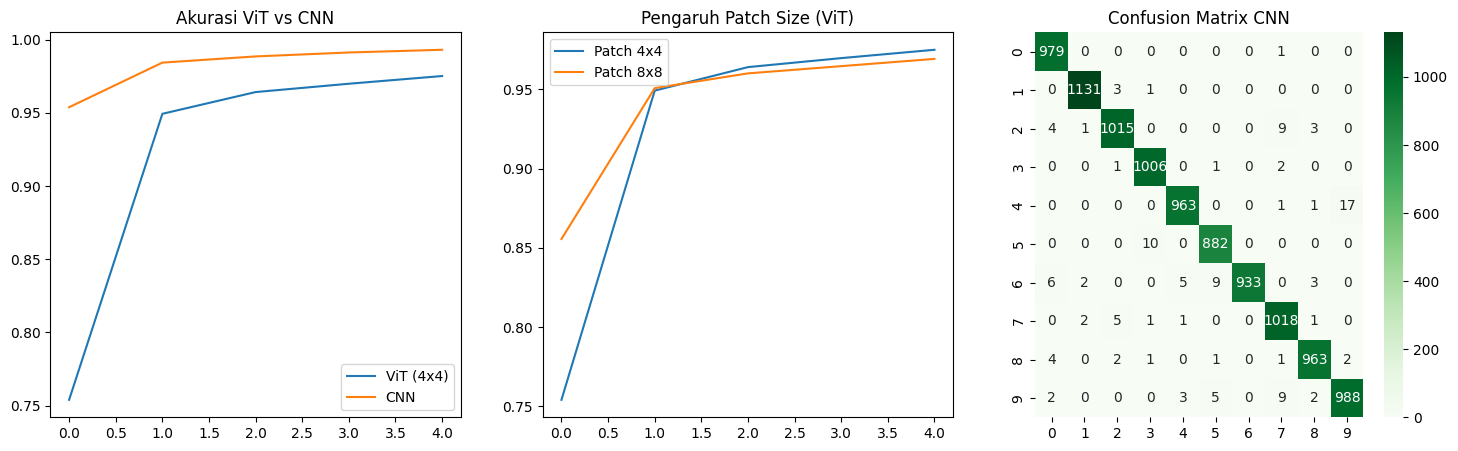


--- Parameter Gambar ---
CNN: 59,786 parameter
ViT: 1,197,706 parameter


In [4]:
# ==========================================
# III. IMPLEMENTASI VISION CLASSIFICATION
# ==========================================
print("Memuat Dataset MNIST (Alternatif CIFAR-10 yang stabil)...")
transform = transforms.Compose([
    transforms.Resize((32, 32)), # Resize ke 32x32 agar cocok dengan patch size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
vis_train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
vis_test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

# Arsitektur ViT
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=1, embed_dim=128):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

class SimpleViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, num_classes=10, embed_dim=128, nhead=4, num_layers=2):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 1, embed_dim)
        num_patches = (img_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        encoder_layers = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.classifier = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        x = self.patch_embed(x) + self.pos_embed
        return self.classifier(self.transformer(x).mean(dim=1))

# Arsitektur CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Linear(64 * 8 * 8, 10)
    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))

# ==========================================
# EKSPERIMEN GAMBAR: ViT VS CNN & PATCH SIZE
# ==========================================
cnn_model = SimpleCNN()
vit_model_4 = SimpleViT(patch_size=4) # Eksperimen Patch 4x4
vit_model_8 = SimpleViT(patch_size=8) # Eksperimen Patch 8x8

cnn_hist = train_model(cnn_model, vis_train_loader, model_name="Simple CNN")
vit_hist_4 = train_model(vit_model_4, vis_train_loader, model_name="ViT (Patch 4x4)")
vit_hist_8 = train_model(vit_model_8, vis_train_loader, model_name="ViT (Patch 8x8)")

# Visualisasi Gambar
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(vit_hist_4['acc'], label='ViT (4x4)'); ax[0].plot(cnn_hist['acc'], label='CNN')
ax[0].set_title('Akurasi ViT vs CNN'); ax[0].legend()

ax[1].plot(vit_hist_4['acc'], label='Patch 4x4'); ax[1].plot(vit_hist_8['acc'], label='Patch 8x8')
ax[1].set_title('Pengaruh Patch Size (ViT)'); ax[1].legend()

y_true_v, y_pred_v, _ = evaluate_model(cnn_model, vis_test_loader)
sns.heatmap(confusion_matrix(y_true_v, y_pred_v), annot=True, fmt='d', cmap='Greens', ax=ax[2])
ax[2].set_title('Confusion Matrix CNN')
plt.show()

print("\n--- Parameter Gambar ---")
print(f"CNN: {count_parameters(cnn_model):,} parameter")
print(f"ViT: {count_parameters(vit_model_4):,} parameter")


Mengunduh gambar pengujian...


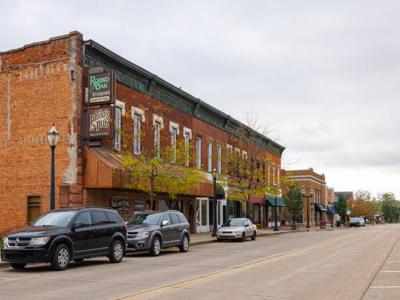

Memuat arsitektur BLIP...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Caption Bawaan (Greedy Search): 'the historic downtown area of the city'
Caption Hasil Modifikasi Kode: 'an old brick building on the corner of a street with cars parked in front of it'


In [7]:
# ==========================================
# IV. EKSPLORASI NON-KLASIFIKASI (IMAGE CAPTIONING)
# ==========================================
!pip install transformers Pillow requests -q

import torch
from PIL import Image
import requests
from transformers import BlipProcessor, BlipForConditionalGeneration
import io

print("\nMengunduh gambar pengujian...")
img_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/segmentation_input.jpg"
response = requests.get(img_url, timeout=15)
raw_image = Image.open(io.BytesIO(response.content)).convert('RGB')
display(raw_image.resize((400, 300)))

# Memuat model BLIP (Transformer Vision + Text)
print("Memuat arsitektur BLIP...")
processor = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-base')
model_blip = BlipForConditionalGeneration.from_pretrained('Salesforce/blip-image-captioning-base').to(device)
inputs = processor(raw_image, return_tensors='pt').to(device)

# INFERENSI 1: Bawaan (Greedy Search)
# Model secara serakah (greedy) memilih kata dengan probabilitas tertinggi satu per satu.
out_default = model_blip.generate(**inputs)
caption_default = processor.decode(out_default[0], skip_special_tokens=True)
print(f"Caption Bawaan (Greedy Search): '{caption_default}'")

# INFERENSI 2: Modifikasi Parameter (Beam Search & Length Penalty)
# MODIFIKASI: Kita mengintervensi algoritma decoding milik Transformer.
# Menggunakan Beam Search (num_beams=5) agar model mempertimbangkan 5 rute kalimat terbaik,
# dan memberikan length_penalty untuk memaksa model menghasilkan kalimat yang lebih panjang/deskriptif.
out_modified = model_blip.generate(
    **inputs,
    max_length=50,
    num_beams=5,
    length_penalty=2.0, # Memaksa kalimat lebih panjang
    repetition_penalty=1.5 # Mencegah kata yang sama diulang
)
caption_modified = processor.decode(out_modified[0], skip_special_tokens=True)
print(f"Caption Hasil Modifikasi Kode: '{caption_modified}'")